Models using ALL data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load cleaned data (from your df_cleaned.csv)
df = pd.read_csv('df_cleaned.csv')

# FIX: Drop rows where native-country is '?' to eliminate unknown categories
df = df[df['native-country'] != '?']  # Drops ~583 rows (~1.8% of data)
print(f"Dataset shape after dropping '?' rows: {df.shape}")

# Group rare native-country values into 'Other' to avoid unknown categories in CV splits
# Avoids errors when infrequently mentioned countries are not in the training or test group
country_counts = df['native-country'].value_counts()
rare_countries = country_counts[country_counts < 50].index  # Threshold of 50
df['native-country'] = df['native-country'].apply(lambda x: 'Other' if x in rare_countries else x)
print("\nUpdated native-country value counts after grouping rares:")
print(df['native-country'].value_counts())

# Define features (exclude target, redundant like fnlwgt/education-num if using education)
features = ['age', 'workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
            'hours-per-week', 'native-country']
X = df[features]  # Features
y = df['income_binary']  # Target (0: <=50K, 1: >50K)

# Identify column types
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                        'relationship', 'race', 'sex', 'native-country']
numeric_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

# Preprocessor: One-hot for categoricals, passthrough for numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified to handle imbalance, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models (balanced weights for imbalance; tune hyperparameters if time allows)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=100000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10),  # Prune to avoid overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)  # Ensemble for robustness
}

# Dictionary for results and fitted pipelines
results = {}
fitted_pipelines = {} # New dictionary to store fitted pipelines

# Loop: Preprocess + Train + Evaluate each model
for name, model in models.items():
    # Pipeline: Preprocess -> Model (ensures consistency)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation on train (5-fold, F1 for imbalance focus)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit on train, predict on test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Store the fitted pipeline
    fitted_pipelines[name] = pipeline # Store the entire fitted pipeline

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store
    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display comparison table
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# Optional: Export to CSV for report (or use df.style for Jupyter table)
results_df.to_csv('model_comparison.csv')

# For feature importance (e.g., Random Forest, for Model Analysis section)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100))])
rf_pipeline.fit(X_train, y_train)
feature_names = (numeric_features +
                 list(rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))
importances = rf_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
print("\nTop 10 Feature Importances (Random Forest):")
print(importance_df.head(10))

# =============================================================================
# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL
# =============================================================================

print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name, _ in models.items(): # No need for 'model' object here, we use fitted_pipelines
    print(f"\n--- {name} ---")

    current_pipeline = fitted_pipelines[name] # Retrieve the specific fitted pipeline
    fitted_model_step = current_pipeline.named_steps['model']

    # Generate feature names for the current pipeline dynamically
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    current_feature_names = np.concatenate([numeric_features, cat_encoder.get_feature_names_out(categorical_features)])


    # 1. Logistic Regression → mathematical equation
    if name == 'Logistic Regression':
        intercept = fitted_model_step.intercept_[0]
        coef = fitted_model_step.coef_[0]

        print(f"Logistic Regression formula (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}")
        for feat, c in zip(current_feature_names, coef): # Use current_feature_names
            if abs(c) > 0.001:                     # only show meaningful coefficients
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    # 2. Decision Tree → readable if-then rules
    elif name == 'Decision Tree':
        from sklearn.tree import export_text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model_step,
                          feature_names=current_feature_names.tolist(), # Use current_feature_names
                          max_depth=5,
                          spacing=3))

    # 3. Random Forest → no single formula, so show top feature importances
    elif name == 'Random Forest':
        importances = fitted_model_step.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': current_feature_names, # Use current_feature_names
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        print("Random Forest is an ensemble of 100 trees → no single formula.")
        print("Top 10 most important features:")
        print(importance_df.head(10).round(4))

Dataset shape after dropping '?' rows: (40852, 14)

Updated native-country value counts after grouping rares:
native-country
United-States         36802
Mexico                  912
Other                   501
Philippines             291
Germany                 202
Puerto-Rico             180
Canada                  177
El-Salvador             153
India                   147
Cuba                    136
England                 123
China                   120
South                   110
Italy                   105
Jamaica                 103
Dominican-Republic      100
Japan                    92
Vietnam                  86
Guatemala                85
Poland                   85
Columbia                 85
Haiti                    71
Portugal                 65
Taiwan                   64
Iran                     57
Name: count, dtype: int64
Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.683 (±0.006)         0.806  

**CONCLUSION - All-Feature Model**

| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.683 (±0.006)    | 0.806         | 0.574          | 0.846       | 0.684   |
| Decision Tree       | 0.670 (±0.003)    | 0.799         | 0.563          | 0.843       | 0.675   |
| Random Forest       | 0.630 (±0.012)    | 0.833         | 0.683          | 0.612       | 0.646   |

**Logistic Regression performs better** in test accuracy and test recall but the test precision was lower than Random Forest.  I hypothesize Logistic Regression performs better because of the granularity from having so many features.  While more accurate, it is computationally expensive to run models this complex.


Model using all date EXCEPT native-country due to native-country errors with "?"


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load cleaned data (from your df_cleaned.csv)
df = pd.read_csv('df_cleaned.csv')

# Define features (exclude target, redundant like fnlwgt/education-num if using education)
features = ['age', 'workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
            'hours-per-week']
X = df[features]  # Features
y = df['income_binary']  # Target (0: <=50K, 1: >50K)

# Identify column types
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                        'relationship', 'race', 'sex']
numeric_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

# Preprocessor: One-hot for categoricals, passthrough for numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified to handle imbalance, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models (balanced weights for imbalance; tune hyperparameters if time allows)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=100000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10),  # Prune to avoid overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)  # Ensemble for robustness
}

# Dictionary for results and fitted pipelines
results = {}
fitted_pipelines = {} # New dictionary to store fitted pipelines

# Loop: Preprocess + Train + Evaluate each model
for name, model in models.items():
    # Pipeline: Preprocess -> Model (ensures consistency)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation on train (5-fold, F1 for imbalance focus)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit on train, predict on test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Store the fitted pipeline
    fitted_pipelines[name] = pipeline # Store the entire fitted pipeline

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store
    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display comparison table
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# Optional: Export to CSV for report (or use df.style for Jupyter table)
results_df.to_csv('model_comparison.csv')

# For feature importance (e.g., Random Forest, for Model Analysis section)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100))])
rf_pipeline.fit(X_train, y_train)
feature_names = (numeric_features +
                 list(rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))
importances = rf_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
print("\nTop 10 Feature Importances (Random Forest):")
print(importance_df.head(10))

# =============================================================================
# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL
# =============================================================================

print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name, _ in models.items(): # No need for 'model' object here, we use fitted_pipelines
    print(f"\n--- {name} ---")

    current_pipeline = fitted_pipelines[name] # Retrieve the specific fitted pipeline
    fitted_model_step = current_pipeline.named_steps['model']

    # Generate feature names for the current pipeline dynamically
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    current_feature_names = np.concatenate([numeric_features, cat_encoder.get_feature_names_out(categorical_features)])


    # 1. Logistic Regression → mathematical equation
    if name == 'Logistic Regression':
        intercept = fitted_model_step.intercept_[0]
        coef = fitted_model_step.coef_[0]

        print(f"Logistic Regression formula (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}")
        for feat, c in zip(current_feature_names, coef): # Use current_feature_names
            if abs(c) > 0.001:                     # only show meaningful coefficients
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    # 2. Decision Tree → readable if-then rules
    elif name == 'Decision Tree':
        from sklearn.tree import export_text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model_step,
                          feature_names=current_feature_names.tolist(), # Use current_feature_names
                          max_depth=5,
                          spacing=3))

    # 3. Random Forest → no single formula, so show top feature importances
    elif name == 'Random Forest':
        importances = fitted_model_step.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': current_feature_names, # Use current_feature_names
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        print("Random Forest is an ensemble of 100 trees → no single formula.")
        print("Top 10 most important features:")
        print(importance_df.head(10).round(4))

Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.681 (±0.005)         0.804          0.572   
Decision Tree          0.667 (±0.007)         0.790          0.550   
Random Forest          0.638 (±0.004)         0.828          0.676   

                    Test Recall Test F1  
Logistic Regression       0.847   0.683  
Decision Tree             0.857   0.670  
Random Forest             0.594   0.633  

Top 10 Feature Importances (Random Forest):
                              Feature  Importance
0                                 age    0.231533
3                      hours-per-week    0.117777
28  marital-status_Married-civ-spouse    0.116023
1                        capital-gain    0.094925
30       marital-status_Never-married    0.049310
2                        capital-loss    0.030272
56                           sex_Male    0.023949
47         relationship_Not-in-family    0.023777
42          occupation_Prof-sp

**CONCLUSION - All-Features Except Native Country Model**

| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | **0.681 (±0.005)**    | 0.804         | 0.572          | **0.847**       | **0.683**   |
| Decision Tree       | 0.667 (±0.007)    | 0.790         | 0.550          | 0.857       | 0.670   |
| Random Forest       | 0.638 (±0.004)    | **0.828**         | **0.676**          | 0.594       | 0.633   |

**Logistic Regression continues to performs better** in test accuracy and test recall but the test precision was lower than Random Forest.  Even without Native Country, I hypothesize Logistic Regression performs better because of the granularity from having so many features.  It is also computationally expensive to run models this complex.

Models with only four education categories


Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.560 (±0.007)         0.723          0.464   
Decision Tree          0.577 (±0.006)         0.728          0.471   
Random Forest          0.576 (±0.005)         0.730          0.473   

                    Test Recall Test F1  
Logistic Regression       0.724   0.566  
Decision Tree             0.757   0.581  
Random Forest             0.754   0.581  

MODEL FORMULAS / RULES

--- Logistic Regression ---
Logistic Regression (log-odds):
   log(p / (1-p)) =   0.0666
                 +   0.5801 * age
                 +  -1.5974 * education_category_HS Graduate
                 +  -2.8606 * education_category_Less than HS
                 +  -1.1218 * education_category_Some College
                 +   1.2436 * sex_Male
(p = probability of income > $50K)

--- Decision Tree ---
Decision Tree rules (first 5 levels):
|--- age <= -0.80
|   |--- age <= -1.10
|   |   |--- age 

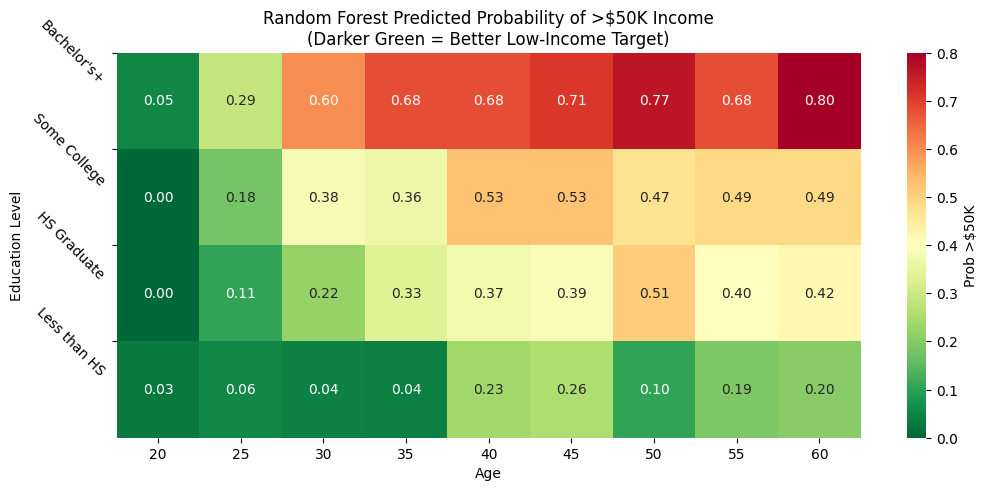

In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('df_cleaned.csv')

# === EDUCATION BINNING (4 categories only) ===
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"

# Apply the binning
df['education_category'] = df['education'].apply(categorize_education)

# === FEATURES (now using binned education) ===
features = ['age', 'education_category', 'sex']
X = df[features]
y = df['income_binary']

# Identify column types
categorical_features = ['education_category', 'sex']
numeric_features = ['age']

# Preprocessor: This code is used to transform data with mixed data (e.g. numerical, catergorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scales numeric features to mean = 0, std_dev = 1
        # OneHotEncoder converts categorical information to arbitrary binary values
         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a library with three models: Logistic Regression, Decision Tree, Random Forest
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, # balanced boosts minority class, random state for reproducibility
                                              solver='liblinear', max_iter=1000), # solver=Optimization algorithm, max_iter=1000 is default and no errors
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10), # pruning; max depth used to prevent overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

# Empty dictionaries to store results and fitted pipelines
results = {}
fitted_pipelines = {}

# Train and evaluate models
# This loop iterates over each model in the 'models' dictionary, applying the same preprocessing
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation, valuates model robustness on train data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit and predict trains the full pipeline on all train data then predicts on held-out test set
    # to gives unbiased performance estimates.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Stores the fitted pipelines by model name (LR, DT, RF)
    fitted_pipelines[name] = pipeline

    # Metrics, calculates test set metrics using scikit-learn functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL (with binned education)
print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name in models.keys():
    print(f"\n--- {name} ---") # Section name for each model
    current_pipeline = fitted_pipelines[name] # Retrieves the fitted model by name
    fitted_model = current_pipeline.named_steps['model']

    # Get feature names (includes binned education_category)
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = np.concatenate([
        numeric_features,
        cat_encoder.get_feature_names_out(categorical_features)
    ])

    if name == 'Logistic Regression':
        intercept = fitted_model.intercept_[0] # Gets the model's intercept
        coef = fitted_model.coef_[0] # Gets the models coefficients
        print("Logistic Regression (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}") # Prints the intercept
        for feat, c in zip(feature_names, coef): # Prints the weight multiplied by feature, eliminates small features with abs(c)>0.001
            if abs(c) > 0.001:
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    elif name == 'Decision Tree':
        from sklearn.tree import export_text # This command converts tree to text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model, feature_names=feature_names.tolist(), # Prints tree in readable text
                          max_depth=5, spacing=3))

    elif name == 'Random Forest':
        importances = fitted_model.feature_importances_ #Feature importances
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=False) # Sort by decending importance
        print("Random Forest (ensemble) \u2192 no single formula")
        print("Top 10 Feature Importances:")
        print(imp_df.head(10).round(4))

print("\n" + "="*80)

# Generate permutations for marketing analysis
ages = [20, 25, 30, 35, 40, 45, 50, 55, 60]
education_bins = ["Less than HS", "HS Graduate", "Some College", "Bachelor's+"]
sexes = ['Male', 'Female']

# Generate all combinations using itertools.product ( 9 ages * 4 educ * 2 sexes = 72 rows)
permutations = list(product(ages, education_bins, sexes)) # Creates the permutations list
perm_df = pd.DataFrame(permutations, columns=['age', 'education_category', 'sex']) # Creates a data frame with labeled columns

# Predict for each model
for name, pipeline in fitted_pipelines.items():
    probs = pipeline.predict_proba(perm_df)[:, 1]  # Predict probabilities: [:, 1] gets prob of class 0 (greater than $50K)
    perm_df[f'{name}_Prob_>50K'] = probs.round(2)
    perm_df[f'{name}_Prediction'] = (probs > 0.5).astype(int)  # Threshold at 0.5 for binary prediction (1 if >$50K)

# Display (or save to CSV for report)
print(perm_df.to_string(index=False))
perm_df.to_csv('permutations_predictions.csv', index=False)

# Heatmap of Random Forest probability by age and education (averaged across sex)
heatmap_data = perm_df.pivot_table(values='Random Forest_Prob_>50K',
                                   index='education_category',
                                   columns='age',
                                   aggfunc='mean')

# This section generates a heatmap to visualize predicted probabilities of >$50K income from the Random Forest model
plt.figure(figsize=(12,5))
# Desired order: bottom-to-top on the plot
desired_order = ["Bachelor's+", "Some College", "HS Graduate", "Less than HS"]
# Reorder the DataFrame so the LAST row in the DF becomes the BOTTOM of the heatmap
heatmap_data = heatmap_data.reindex(desired_order)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Prob >$50K'})
plt.title('Random Forest Predicted Probability of >$50K Income\n(Darker Green = Better Low-Income Target)')
plt.ylabel('Education Level')
plt.xlabel('Age')
plt.yticks(ticks=range(len(heatmap_data.index)), labels=heatmap_data.index, fontsize=10, rotation=-45)
plt.show()


**CONCLUSION - Four-Feature Model (Age, Sex, Education, Income)**
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.560 (±0.007)    | 0.723         | 0.464          | 0.724       | 0.566   |
| Decision Tree       | 0.577 (±0.006)    | 0.728         | 0.471          | **0.757**   | **0.581** |
| Random Forest       | 0.576 (±0.005)    | **0.730**     | **0.473**      | 0.754       | **0.581** |

**RANDOM FOREST**.Compared to models trained on the full set of features, these numbers are noticeably lower. This is expected due to removing many strong predictors (capital-gain, capital-loss, hours-per-week, occupation, workclass, native-country) used in the full data set analysis so the models have much less information to work with.

For our Marketing Department, the removed data sets make their analysis easier.

Models with only four education categories and two married categories


Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.584 (±0.005)         0.736          0.481   
Decision Tree          0.593 (±0.005)         0.736          0.482   
Random Forest          0.592 (±0.002)         0.736          0.482   

                    Test Recall Test F1  
Logistic Regression       0.751   0.586  
Decision Tree             0.811   0.604  
Random Forest             0.806   0.603  

MODEL FORMULAS / RULES

--- Logistic Regression ---
Logistic Regression (log-odds):
   log(p / (1-p)) =   0.5530
                 +   0.7138 * age
                 +  -1.5529 * education_category_HS Graduate
                 +  -2.8813 * education_category_Less than HS
                 +  -1.0906 * education_category_Some College
                 +   0.8748 * sex_Male
                 +  -1.4327 * marriage_category_Not Married
(p = probability of income > $50K)

--- Decision Tree ---
Decision Tree rules (first 5 levels

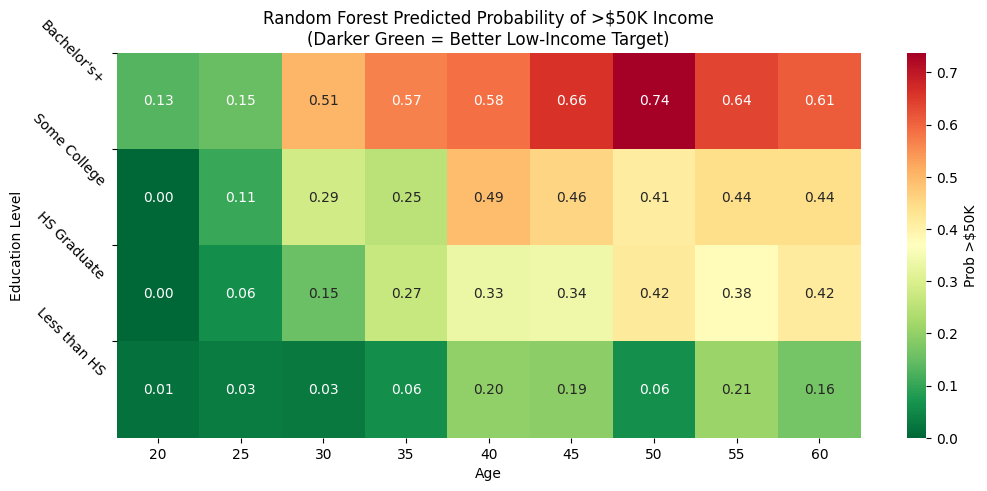

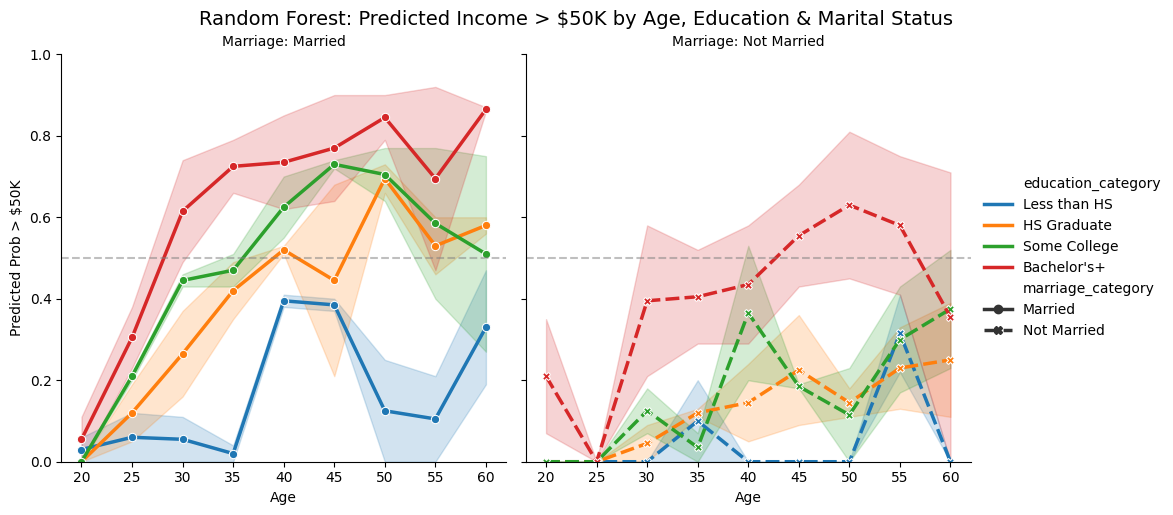

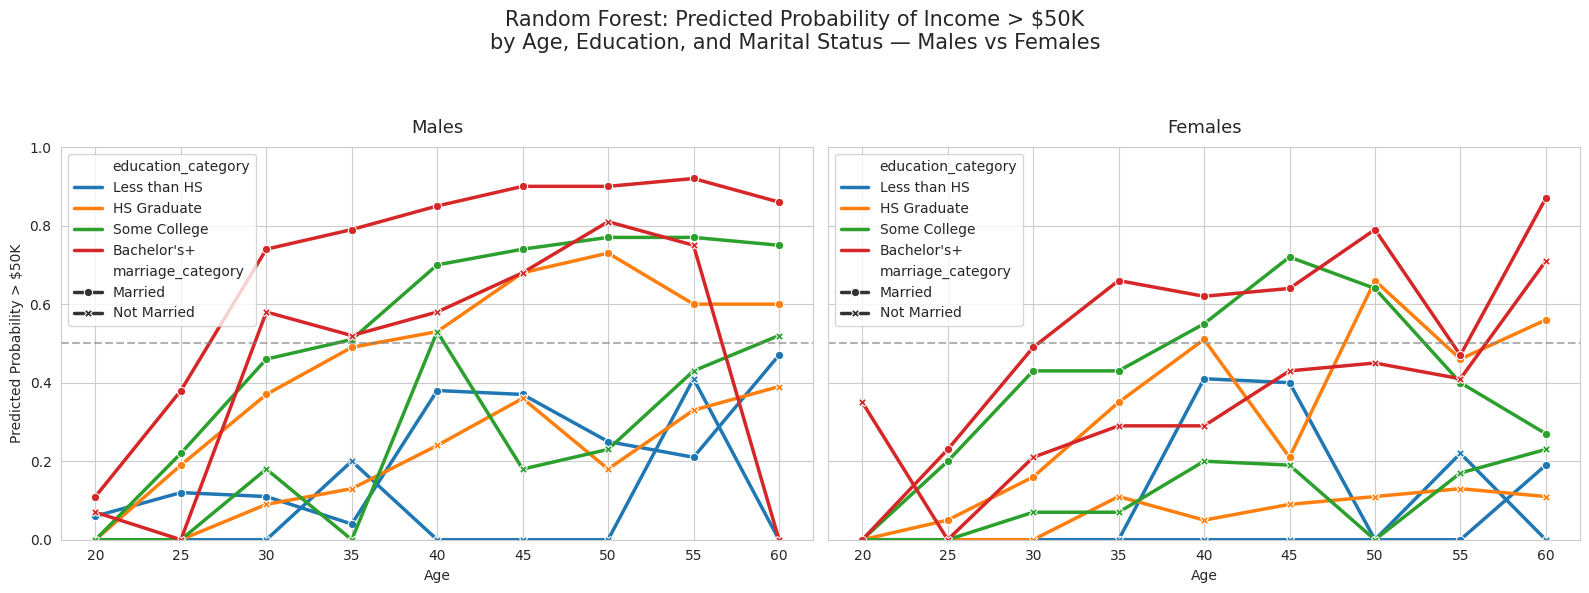

In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('df_cleaned.csv')

# === EDUCATION BINNING (4 categories only) ===
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"

# Apply the binning
df['education_category'] = df['education'].apply(categorize_education)

# === Marriage Binning (2 categories only) ===
# Looking at the original Linear Regression Model the 5 not_married categories had a negative effect on probability
def categorize_marriage(mar):
    """Simplify marriage levels into 2 meaningful groups."""
    not_married = ['Divorced', 'Never-Married', 'Separated', 'Widowed', 'Married-spouse-absent']
    married = ['Married-civ-spouse', 'Married-AF-spouse']

    if mar in not_married:
        return 'Not Married'
    else:
        return "Married"

# Apply the binning
df['marriage_category'] = df['marital-status'].apply(categorize_marriage)

# === FEATURES (now using binned education) ===
features = ['age', 'education_category', 'sex', 'marriage_category']
X = df[features]
y = df['income_binary']

# Identify column types
categorical_features = ['education_category', 'sex', 'marriage_category']
numeric_features = ['age']

# Preprocessor: This code is used to transform data with mixed data (e.g. numerical, catergorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scales numeric features to mean = 0, std_dev = 1
        # OneHotEncoder converts categorical information to arbitrary binary values
         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a library with three models: Logistic Regression, Decision Tree, Random Forest
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, # balanced boosts minority class, random state for reproducibility
                                              solver='liblinear', max_iter=1000), # solver=Optimization algorithm, max_iter=1000 is default and no errors
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10), # pruning; max depth used to prevent overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

# Empty dictionaries to store results and fitted pipelines
results = {}
fitted_pipelines = {}

# Train and evaluate models
# This loop iterates over each model in the 'models' dictionary, applying the same preprocessing
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation, valuates model robustness on train data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit and predict trains the full pipeline on all train data then predicts on held-out test set
    # to gives unbiased performance estimates.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Stores the fitted pipelines by model name (LR, DT, RF)
    fitted_pipelines[name] = pipeline

    # Metrics, calculates test set metrics using scikit-learn functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL (with binned education)
print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name in models.keys():
    print(f"\n--- {name} ---") # Section name for each model
    current_pipeline = fitted_pipelines[name] # Retrieves the fitted model by name
    fitted_model = current_pipeline.named_steps['model']

    # Get feature names (includes binned education_category)
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = np.concatenate([
        numeric_features,
        cat_encoder.get_feature_names_out(categorical_features)
    ])

    if name == 'Logistic Regression':
        intercept = fitted_model.intercept_[0] # Gets the model's intercept
        coef = fitted_model.coef_[0] # Gets the models coefficients
        print("Logistic Regression (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}") # Prints the intercept
        for feat, c in zip(feature_names, coef): # Prints the weight multiplied by feature, eliminates small features with abs(c)>0.001
            if abs(c) > 0.001:
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    elif name == 'Decision Tree':
        from sklearn.tree import export_text # This command converts tree to text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model, feature_names=feature_names.tolist(), # Prints tree in readable text
                          max_depth=5, spacing=3))

    elif name == 'Random Forest':
        importances = fitted_model.feature_importances_ #Feature importances
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=False) # Sort by decending importance
        print("Random Forest (ensemble) \u2192 no single formula")
        print("Top 10 Feature Importances:")
        print(imp_df.head(10).round(4))

print("\n" + "="*80)

# Generate permutations for marketing analysis
ages = [20, 25, 30, 35, 40, 45, 50, 55, 60]
education_bins = ["Less than HS", "HS Graduate", "Some College", "Bachelor's+"]
sexes = ['Male', 'Female']
marriage_bins = ['Married', 'Not Married'] # Add marriage categories

# Generate all combinations using itertools.product ( 9 ages * 4 educ * 2 sexes * 2 marriage = 144 rows)
permutations = list(product(ages, education_bins, sexes, marriage_bins)) # Add marriage_bins
perm_df = pd.DataFrame(permutations, columns=['age', 'education_category', 'sex', 'marriage_category']) # Add marriage_category

# Predict for each model
for name, pipeline in fitted_pipelines.items():
    probs = pipeline.predict_proba(perm_df)[:, 1]  # Predict probabilities: [:, 1] gets prob of class 0 (greater than $50K)
    perm_df[f'{name}_Prob_>50K'] = probs.round(2)
    perm_df[f'{name}_Prediction'] = (probs > 0.5).astype(int)  # Threshold at 0.5 for binary prediction (1 if >$50K)

# Display (or save to CSV for report)
print(perm_df.to_string(index=False))
perm_df.to_csv('permutations_predictions.csv', index=False)

# Heatmap of Random Forest probability by age and education (averaged across sex)
heatmap_data = perm_df.pivot_table(values='Random Forest_Prob_>50K',
                                   index='education_category',
                                   columns='age',
                                   aggfunc='mean')

# This section generates a heatmap to visualize predicted probabilities of >$50K income from the Random Forest model
plt.figure(figsize=(12,5))
# Desired order: bottom-to-top on the plot
desired_order = ["Bachelor's+", "Some College", "HS Graduate", "Less than HS"]
# Reorder the DataFrame so the LAST row in the DF becomes the BOTTOM of the heatmap
heatmap_data = heatmap_data.reindex(desired_order)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Prob >$50K'})
plt.title('Random Forest Predicted Probability of >$50K Income\n(Darker Green = Better Low-Income Target)')
plt.ylabel('Education Level')
plt.xlabel('Age')
plt.yticks(ticks=range(len(heatmap_data.index)), labels=heatmap_data.index, fontsize=10, rotation=-45)
plt.show()

# FACETED LINE PLOT: Probability vs Age, separated by Marriage + Education
# Shows clear life-cycle / age trajectory differences
# -----------------------------------------------------------------------------
g = sns.relplot(
    data=perm_df,
    x='age',
    y='Random Forest_Prob_>50K',           # Best Model F1 > 0.60
    hue='education_category',
    style='marriage_category',             # different markers/lines for Married vs Not Married
    col='marriage_category',               # separate panels for Married / Not Married
    kind='line',
    palette='tab10',
    linewidth=2.5,
    markers=True,
    facet_kws={'sharey': True, 'sharex': True}
)

g.set_titles("Marriage: {col_name}")
g.set_axis_labels("Age", "Predicted Prob > $50K")
g.fig.suptitle("Random Forest: Predicted Income > $50K by Age, Education & Marital Status", y=1.02, fontsize=14)
g.set(ylim=(0,1))

# Add a reference line at 0.5
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)

plt.show()

# Male vs. Female
# -------------------------
sns.set_style("whitegrid")

# Create figure with two side-by-side subplots (share y-axis)
fig, (ax_male, ax_female) = plt.subplots(1, 2, figsize=(16, 6), sharey=True, sharex=True)

# Left: Males
sns.lineplot(
    data=perm_df[perm_df['sex'] == 'Male'],
    x='age',
    y='Random Forest_Prob_>50K',
    hue='education_category',
    style='marriage_category',
    palette='tab10',
    linewidth=2.5,
    markers=True,
    dashes=False,
    ax=ax_male
)

ax_male.set_title("Males", fontsize=13, pad=10)
ax_male.set_xlabel("Age")
ax_male.set_ylabel("Predicted Probability > $50K")
ax_male.set_ylim(0, 1)
ax_male.axhline(0.5, color='gray', ls='--', alpha=0.6)

# Right: Females
sns.lineplot(
    data=perm_df[perm_df['sex'] == 'Female'],
    x='age',
    y='Random Forest_Prob_>50K',
    hue='education_category',
    style='marriage_category',
    palette='tab10',
    linewidth=2.5,
    markers=True,
    dashes=False,
    ax=ax_female
)

ax_female.set_title("Females", fontsize=13, pad=10)
ax_female.set_xlabel("Age")
# No ylabel on right plot since we share y-axis
ax_female.axhline(0.5, color='gray', ls='--', alpha=0.6)
ax_female.set_ylim(0, 1)

# Overall title
fig.suptitle("Random Forest: Predicted Probability of Income > $50K\nby Age, Education, and Marital Status — Males vs Females",
             fontsize=15, y=1.02)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

**CONCLUSION - Five-Feature Model (Age, Sex, Education, Income, Marital Status)**
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.584 (±0.005)    | 0.736         | 0.481          | 0.751       | 0.586   |
| Decision Tree       | 0.593 (±0.005)    | 0.736         | 0.482          | **0.811**   | **0.604** |
| Random Forest       | 0.592 (±0.002)    | 0.736         | 0.482          | 0.806       | 0.603   |

**Decision Tree edges out based on test recall.** The Five-Parameter evaluation performs better than the Four-Parameter evaluation for all three models.  All three models (LR, DT, RF) have a 73.6% test accuracy.  The model recall is high at 75.1-81.1% meaning the model is finding over 75% of people making over 50K.  But, the precision is low at 48% meaning the model is over-predicting those making over 50K per year.  This limits our target demographic as we look for those making **Less Than $50K Per Year**.

Six-Parameter Model (Age, Sex, Gender, Education, Marital Status, Working Hours)

Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.592 (±0.004)         0.743          0.489   
Decision Tree          0.603 (±0.005)         0.739          0.486   
Random Forest          0.574 (±0.005)         0.752          0.501   

                    Test Recall Test F1  
Logistic Regression       0.774   0.599  
Decision Tree             0.805   0.606  
Random Forest             0.682   0.577  

MODEL FORMULAS / RULES

--- Logistic Regression ---
Logistic Regression (log-odds):
   log(p / (1-p)) =   0.6062
                 +   0.7499 * age
                 +   0.5104 * hours-per-week
                 +  -1.5029 * education_category_HS Graduate
                 +  -2.7806 * education_category_Less than HS
                 +  -1.0147 * education_category_Some College
                 +   0.6353 * sex_Male
                 +  -1.4918 * marriage_category_Not Married
(p = probability of income > $50K)

--- Decision

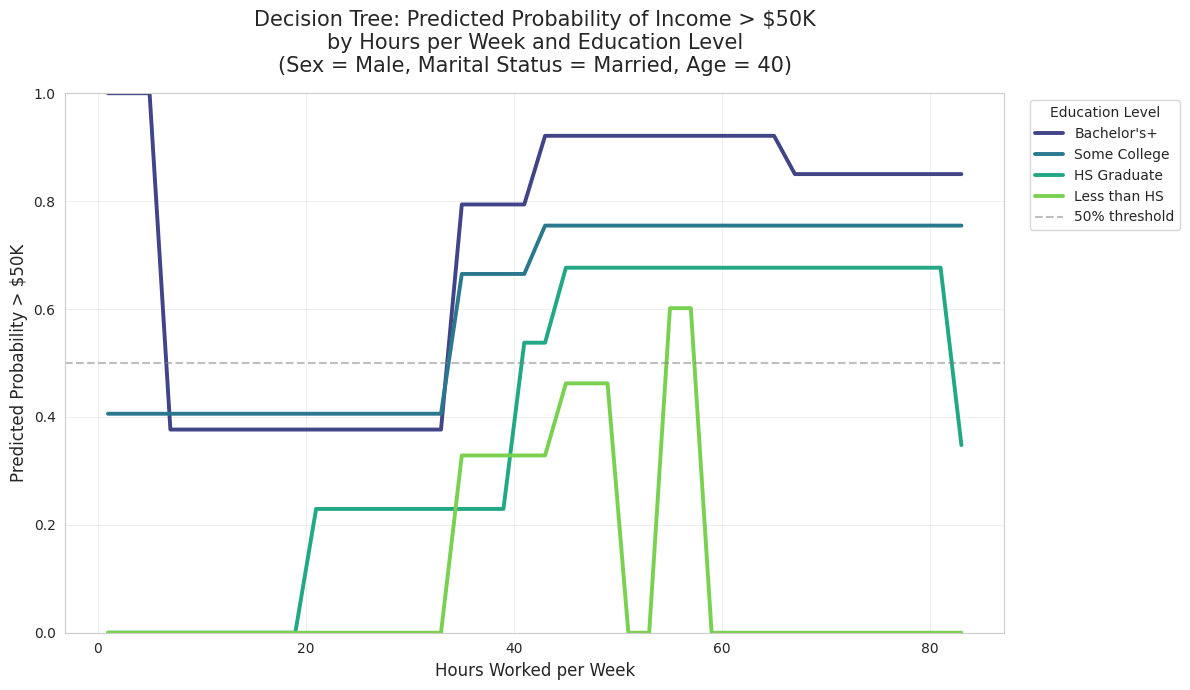

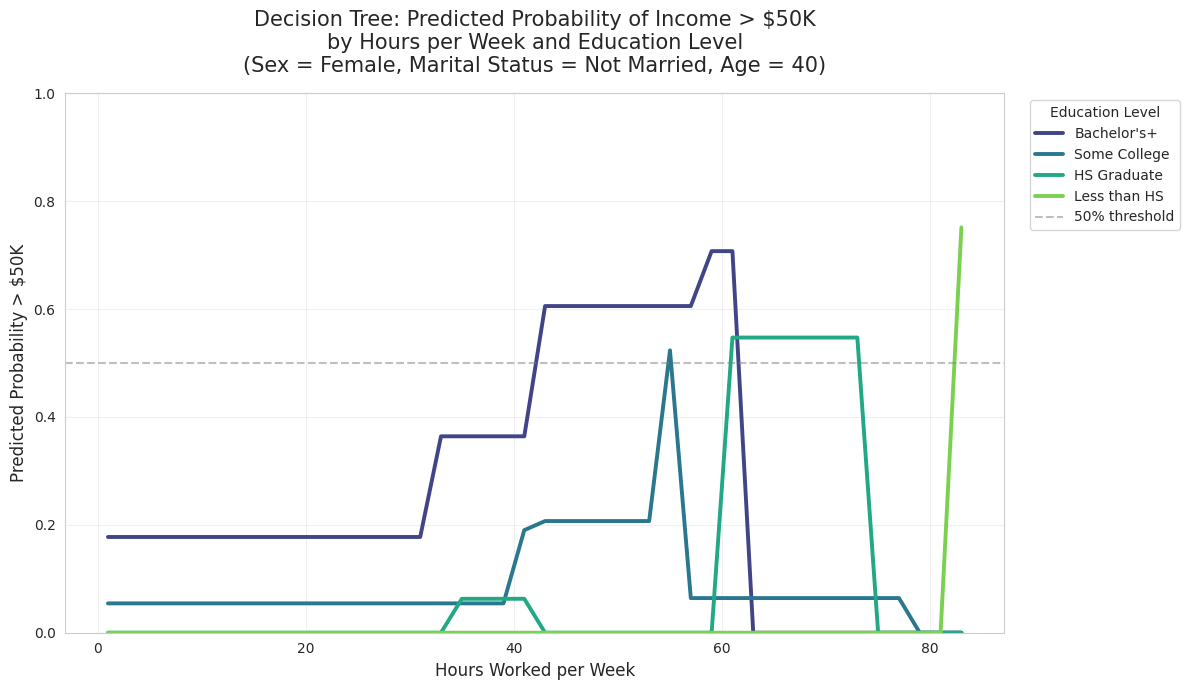

In [5]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('df_cleaned.csv')

# === EDUCATION BINNING (4 categories only) ===
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"

# Apply the binning
df['education_category'] = df['education'].apply(categorize_education)

# === Marriage Binning (2 categories only) ===
# Looking at the original Linear Regression Model the 5 not_married categories had a negative effect on probability
def categorize_marriage(mar):
    """Simplify marriage levels into 2 meaningful groups."""
    not_married = ['Divorced', 'Never-Married', 'Separated', 'Widowed', 'Married-spouse-absent']
    married = ['Married-civ-spouse', 'Married-AF-spouse']

    if mar in not_married:
        return 'Not Married'
    else:
        return "Married"

# Apply the binning
df['marriage_category'] = df['marital-status'].apply(categorize_marriage)


# === FEATURES (now using binned education) ===
features = ['age', 'education_category', 'sex', 'marriage_category', 'hours-per-week']
X = df[features]
y = df['income_binary']

# Identify column types
categorical_features = ['education_category', 'sex', 'marriage_category']
numeric_features = ['age', 'hours-per-week']

# Preprocessor: This code is used to transform data with mixed data (e.g. numerical, catergorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scales numeric features to mean = 0, std_dev = 1
        # OneHotEncoder converts categorical information to arbitrary binary values
         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a library with three models: Logistic Regression, Decision Tree, Random Forest
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, # balanced boosts minority class, random state for reproducibility
                                              solver='liblinear', max_iter=1000), # solver=Optimization algorithm, max_iter=1000 is default and no errors
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10), # pruning; max depth used to prevent overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

# Empty dictionaries to store results and fitted pipelines
results = {}
fitted_pipelines = {}

# Train and evaluate models
# This loop iterates over each model in the 'models' dictionary, applying the same preprocessing
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation, valuates model robustness on train data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit and predict trains the full pipeline on all train data then predicts on held-out test set
    # to gives unbiased performance estimates.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Stores the fitted pipelines by model name (LR, DT, RF)
    fitted_pipelines[name] = pipeline

    # Metrics, calculates test set metrics using scikit-learn functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL (with binned education)
print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name in models.keys():
    print(f"\n--- {name} ---") # Section name for each model
    current_pipeline = fitted_pipelines[name] # Retrieves the fitted model by name
    fitted_model = current_pipeline.named_steps['model']

    # Get feature names (includes binned education_category)
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = np.concatenate([
        numeric_features,
        cat_encoder.get_feature_names_out(categorical_features)
    ])

    if name == 'Logistic Regression':
        intercept = fitted_model.intercept_[0] # Gets the model's intercept
        coef = fitted_model.coef_[0] # Gets the models coefficients
        print("Logistic Regression (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}") # Prints the intercept
        for feat, c in zip(feature_names, coef): # Prints the weight multiplied by feature, eliminates small features with abs(c)>0.001
            if abs(c) > 0.001:
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    elif name == 'Decision Tree':
        from sklearn.tree import export_text # This command converts tree to text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model, feature_names=feature_names.tolist(), # Prints tree in readable text
                          max_depth=5, spacing=3))

    elif name == 'Random Forest':
        importances = fitted_model.feature_importances_ #Feature importances
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=False) # Sort by decending importance
        print("Random Forest (ensemble) \u2192 no single formula")
        print("Top 10 Feature Importances:")
        print(imp_df.head(10).round(4))

print("\n" + "="*80)

# Create a Visualization – Male
# Realistic range of hours-per-week
hours_range = np.arange(1, 85, 2)   # 1 to 84 hours (12 hrs/day for 7 days)

# Fixed values for other variables (you can experiment with these)
fixed_sex = 'Male'                  # or 'Female'
fixed_marriage = 'Married'          # or 'Not Married'
fixed_age = 40                      # Add a fixed age

# All four education levels
edu_levels = ["Less than HS", "HS Graduate", "Some College", "Bachelor's+"]

# Create full grid
plot_grid = pd.DataFrame(list(product(hours_range, edu_levels)),
                         columns=['hours-per-week', 'education_category'])

# Add fixed columns
plot_grid['sex'] = fixed_sex
plot_grid['marriage_category'] = fixed_marriage
plot_grid['age'] = fixed_age

# ────────────────────────────────────────
# 2. Predict probabilities using Decision Tree
# ────────────────────────────────────────

dt_pipeline = fitted_pipelines['Decision Tree']   # ← Changed to Decision Tree

# Get probability of class 1 (>50K)
probs = dt_pipeline.predict_proba(plot_grid)[:, 1]

# Add to dataframe
plot_grid['Prob_>50K'] = probs

# ────────────────────────────────────────
# 3. Create the line plot
# ────────────────────────────────────────

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=plot_grid,
    x='hours-per-week',
    y='Prob_>50K',
    hue='education_category',
    hue_order=["Bachelor's+", "Some College", "HS Graduate", "Less than HS"],  # high to low
    palette='viridis',          # or try 'tab10', 'bright', 'Set1' for more vivid colors
    linewidth=2.8,
    markers=True,
    dashes=False
)

plt.title(f"Decision Tree: Predicted Probability of Income > $50K\n"   # ← Updated title
          f"by Hours per Week and Education Level\n"
          f"(Sex = {fixed_sex}, Marital Status = {fixed_marriage}, Age = {fixed_age})",
          fontsize=15, pad=15)

plt.xlabel("Hours Worked per Week", fontsize=12)
plt.ylabel("Predicted Probability > $50K", fontsize=12)

plt.ylim(0, 1)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')

plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ========================================================================
# Create a Visualization – Female
# Realistic range of hours-per-week
hours_range = np.arange(1, 85, 2)   # 1 to 84 hours (12 hrs/day for 7 days)

# Fixed values for other variables (you can experiment with these)
fixed_sex = 'Female'                # Changed to Female
fixed_marriage = 'Not Married'      # Changed as in your second plot
fixed_age = 40                      # Add a fixed age

# All four education levels
edu_levels = ["Less than HS", "HS Graduate", "Some College", "Bachelor's+"]

# Create full grid
plot_grid = pd.DataFrame(list(product(hours_range, edu_levels)),
                         columns=['hours-per-week', 'education_category'])

# Add fixed columns
plot_grid['sex'] = fixed_sex
plot_grid['marriage_category'] = fixed_marriage
plot_grid['age'] = fixed_age

# ────────────────────────────────────────
# 2. Predict probabilities using Decision Tree
# ────────────────────────────────────────

dt_pipeline = fitted_pipelines['Decision Tree']   # ← Changed to Decision Tree

# Get probability of class 1 (>50K)
probs = dt_pipeline.predict_proba(plot_grid)[:, 1]

# Add to dataframe
plot_grid['Prob_>50K'] = probs

# ────────────────────────────────────────
# 3. Create the line plot
# ────────────────────────────────────────

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=plot_grid,
    x='hours-per-week',
    y='Prob_>50K',
    hue='education_category',
    hue_order=["Bachelor's+", "Some College", "HS Graduate", "Less than HS"],  # high to low
    palette='viridis',          # or try 'tab10', 'bright', 'Set1' for more vivid colors
    linewidth=2.8,
    markers=True,
    dashes=False
)

plt.title(f"Decision Tree: Predicted Probability of Income > $50K\n"   # ← Updated title
          f"by Hours per Week and Education Level\n"
          f"(Sex = {fixed_sex}, Marital Status = {fixed_marriage}, Age = {fixed_age})",
          fontsize=15, pad=15)

plt.xlabel("Hours Worked per Week", fontsize=12)
plt.ylabel("Predicted Probability > $50K", fontsize=12)

plt.ylim(0, 1)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')

plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**CONCLUSION - Six-Parameter Model**
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.592 (±0.004)    | 0.743         | 0.489          | 0.774       | 0.599   |
| Decision Tree       | 0.603 (±0.005)    | 0.739         | 0.486          | **0.805**   | **0.606** |
| Random Forest       | 0.574 (±0.005)    | **0.752**     | **0.501**      | 0.682       | 0.577   |

**TOSS-UP: DECISION TREE and RANDOM FOREST**.  Both models have strengths.  Decision Tree is better at identifying >50K earners from new data (Recall) and overall F1 score.

Seven-Parameter Model (Age, Gender, Education (binned), Marriage (binned), Profession (binned), Income (binned), hours)

In [6]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('df_cleaned.csv')

# === EDUCATION BINNING (4 categories only) ===
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"

# Apply the binning
df['education_category'] = df['education'].apply(categorize_education)

# === Marriage Binning (2 categories only) ===
# Looking at the original Linear Regression Model the 5 not_married categories had a negative effect on probability
def categorize_marriage(mar):
    """Simplify marriage levels into 2 meaningful groups."""
    not_married = ['Divorced', 'Never-Married', 'Separated', 'Widowed', 'Married-spouse-absent']
    married = ['Married-civ-spouse', 'Married-AF-spouse']

    if mar in not_married:
        return 'Not Married'
    else:
        return "Married"

# Apply the marriage binning
df['marriage_category'] = df['marital-status'].apply(categorize_marriage)

# === Occupation Binning (2 categories only) ===
# Looking at the original Linear Regression Model, White Collar+First Responders give the highest weights
def categorize_occupation(occ):
    """Simplify occupation levels into 2 meaningful groups."""
    professional = ['Exec-managerial', 'Prof-specialty', 'Protective-serv', 'Tech-support', 'Sales', 'Craft-repair', 'Transport-moving']
    non_professional = ['Priv-house-serv', 'Farming-fishing', 'Other-service', 'Handlers-cleaners', 'Machine-op-inspct', 'Adm-clerical', 'Armed-Forces']

    if occ in professional:
        return 'professional'
    else:
        return "non-professional"

# Apply the occupation binning
df['occupation_category'] = df['occupation'].apply(categorize_occupation)

# === FEATURES (now using binned education) ===
features = ['age', 'education_category', 'sex', 'marriage_category', 'hours-per-week', 'occupation_category']
X = df[features]
y = df['income_binary']

# Identify column types
categorical_features = ['education_category', 'sex', 'marriage_category', 'occupation_category']
numeric_features = ['age', 'hours-per-week']

# Preprocessor: This code is used to transform data with mixed data (e.g. numerical, catergorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scales numeric features to mean = 0, std_dev = 1
        # OneHotEncoder converts categorical information to arbitrary binary values
         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a library with three models: Logistic Regression, Decision Tree, Random Forest
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, # balanced boosts minority class, random state for reproducibility
                                              solver='liblinear', max_iter=1000), # solver=Optimization algorithm, max_iter=1000 is default and no errors
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10), # pruning; max depth used to prevent overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

# Empty dictionaries to store results and fitted pipelines
results = {}
fitted_pipelines = {}

# Train and evaluate models
# This loop iterates over each model in the 'models' dictionary, applying the same preprocessing
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation, valuates model robustness on train data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit and predict trains the full pipeline on all train data then predicts on held-out test set
    # to gives unbiased performance estimates.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Stores the fitted pipelines by model name (LR, DT, RF)
    fitted_pipelines[name] = pipeline

    # Metrics, calculates test set metrics using scikit-learn functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL (with binned education)
print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name in models.keys():
    print(f"\n--- {name} ---") # Section name for each model
    current_pipeline = fitted_pipelines[name] # Retrieves the fitted model by name
    fitted_model = current_pipeline.named_steps['model']

    # Get feature names (includes binned education_category)
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = np.concatenate([
        numeric_features,
        cat_encoder.get_feature_names_out(categorical_features)
    ])

    if name == 'Logistic Regression':
        intercept = fitted_model.intercept_[0] # Gets the model's intercept
        coef = fitted_model.coef_[0] # Gets the models coefficients
        print("Logistic Regression (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}") # Prints the intercept
        for feat, c in zip(feature_names, coef): # Prints the weight multiplied by feature, eliminates small features with abs(c)>0.001
            if abs(c) > 0.001:
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    elif name == 'Decision Tree':
        from sklearn.tree import export_text # This command converts tree to text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model, feature_names=feature_names.tolist(), # Prints tree in readable text
                          max_depth=5, spacing=3))

    elif name == 'Random Forest':
        importances = fitted_model.feature_importances_ #Feature importances
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=False) # Sort by decending importance
        print("Random Forest (ensemble) \u2192 no single formula")
        print("Top 10 Feature Importances:")
        print(imp_df.head(10).round(4))

print("\n" + "="*80)


Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.600 (±0.003)         0.745          0.493   
Decision Tree          0.601 (±0.004)         0.747          0.495   
Random Forest          0.576 (±0.005)         0.759          0.512   

                    Test Recall Test F1  
Logistic Regression       0.789   0.607  
Decision Tree             0.818   0.616  
Random Forest             0.677   0.583  

MODEL FORMULAS / RULES

--- Logistic Regression ---
Logistic Regression (log-odds):
   log(p / (1-p)) =  -0.0543
                 +   0.7461 * age
                 +   0.4591 * hours-per-week
                 +  -1.2651 * education_category_HS Graduate
                 +  -2.4792 * education_category_Less than HS
                 +  -0.8538 * education_category_Some College
                 +   0.5033 * sex_Male
                 +  -1.5146 * marriage_category_Not Married
                 +   0.8917 * occupation_categor

**CONCLUSION - Seven-Parameter Model**
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.600 (±0.003)    | 0.745         | 0.493          | 0.789       | 0.607   |
| Decision Tree       | 0.601 (±0.004)    | 0.747         | 0.495          | **0.818**   | **0.616** |
| Random Forest       | 0.576 (±0.005)    | **0.759**     | **0.512**      | 0.677       | 0.583   |

**DECISION TREE is the best overall performer.**  This 7-factor model produces the best recall to identify individuals making >50K based on new data.  RANDOM FOREST has the best accuracy but misses more >50K earners based on the significantly lower recall percentage.

Eight-Parameter Model [Age, Gender, Education (binned), Marriage (binned), Profession (binned), Income (binned), hours, capital activity (yes/no)]

Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.621 (±0.005)         0.761          0.513   
Decision Tree          0.619 (±0.006)         0.754          0.504   
Random Forest          0.584 (±0.007)         0.768          0.528   

                    Test Recall Test F1  
Logistic Regression       0.792   0.623  
Decision Tree             0.803   0.619  
Random Forest             0.647   0.581  

MODEL FORMULAS / RULES

--- Logistic Regression ---
Logistic Regression (log-odds):
   log(p / (1-p)) =   1.1448
                 +   0.7163 * age
                 +   0.4478 * hours-per-week
                 +  -1.2104 * education_category_HS Graduate
                 +  -2.3830 * education_category_Less than HS
                 +  -0.7841 * education_category_Some College
                 +   0.4869 * sex_Male
                 +  -1.5311 * marriage_category_Not Married
                 +   0.8638 * occupation_categor

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


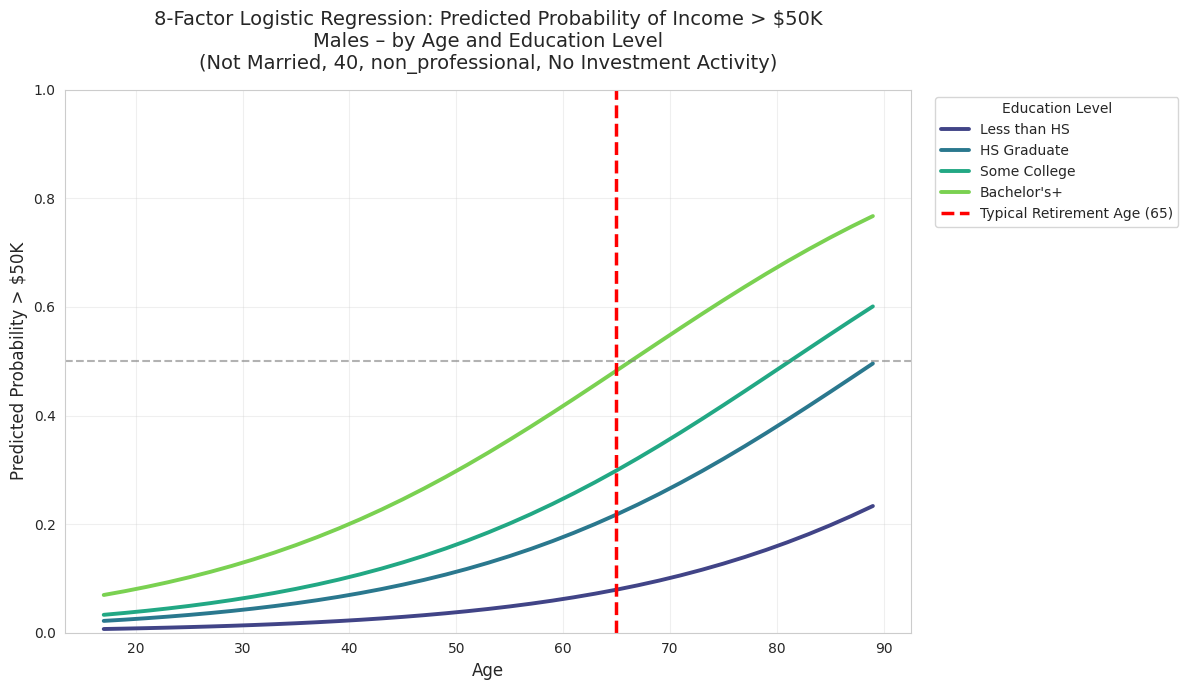

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


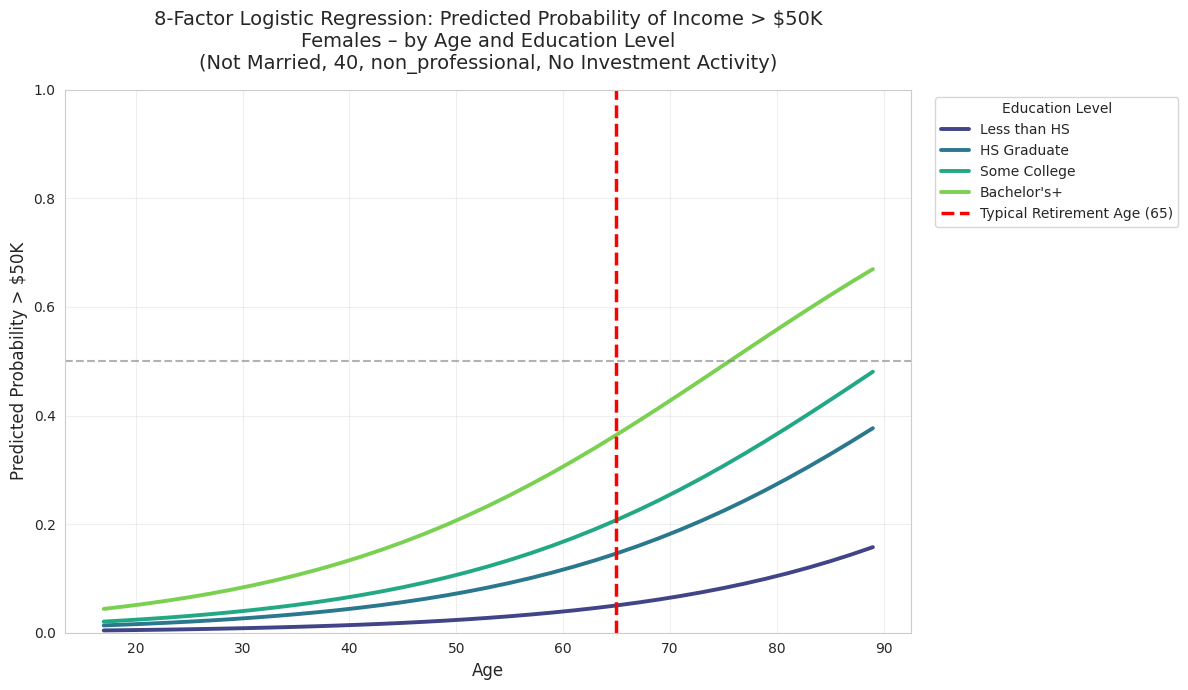

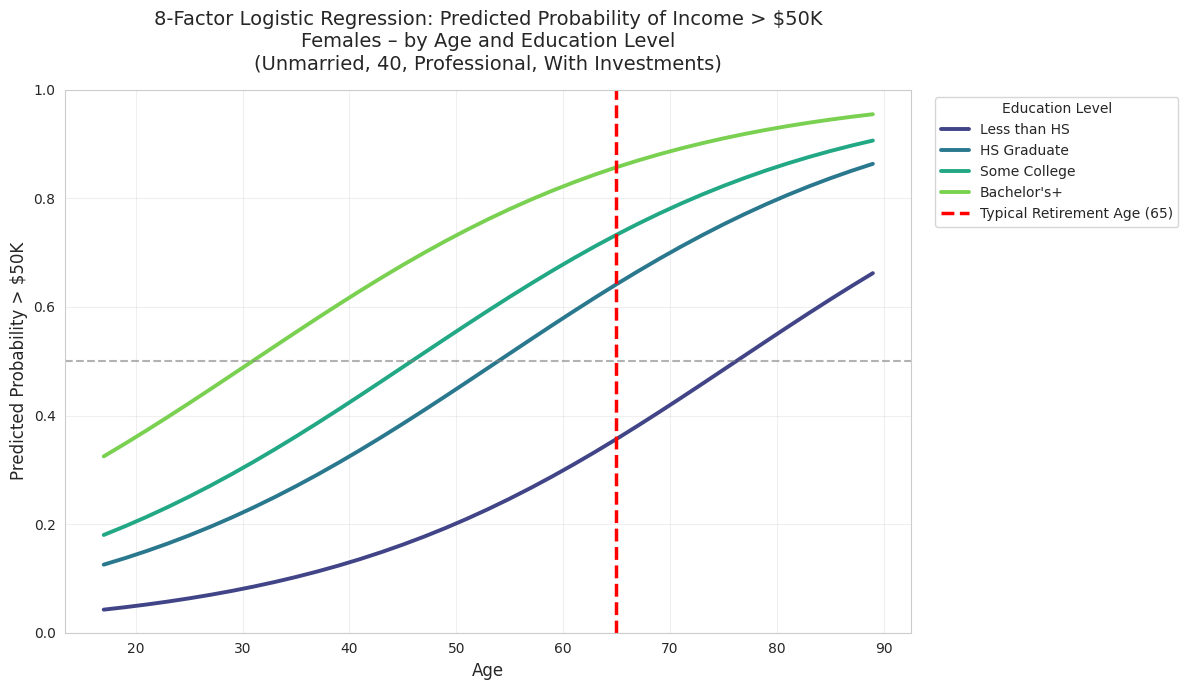

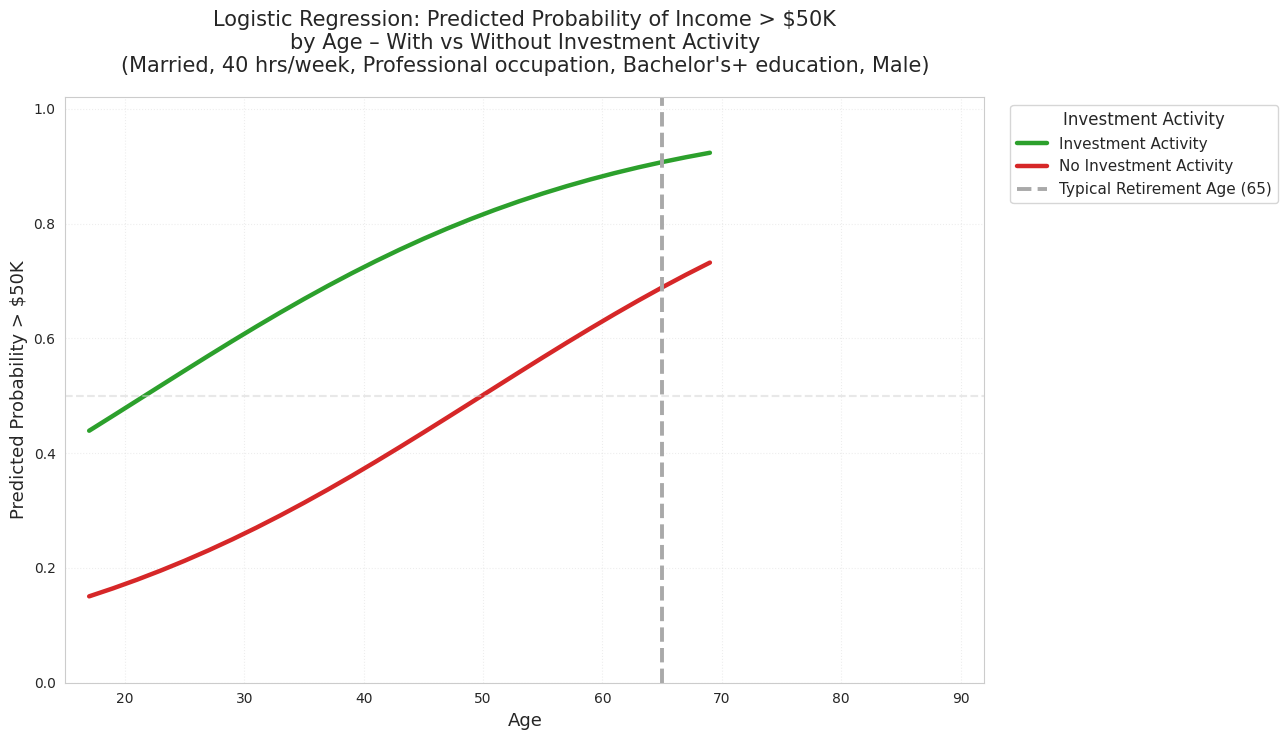

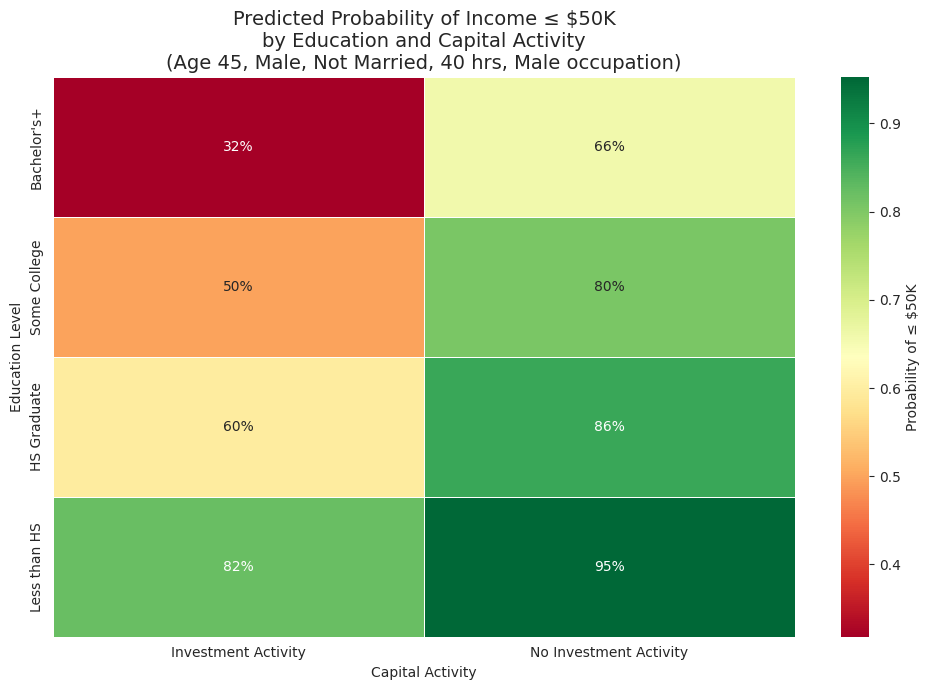

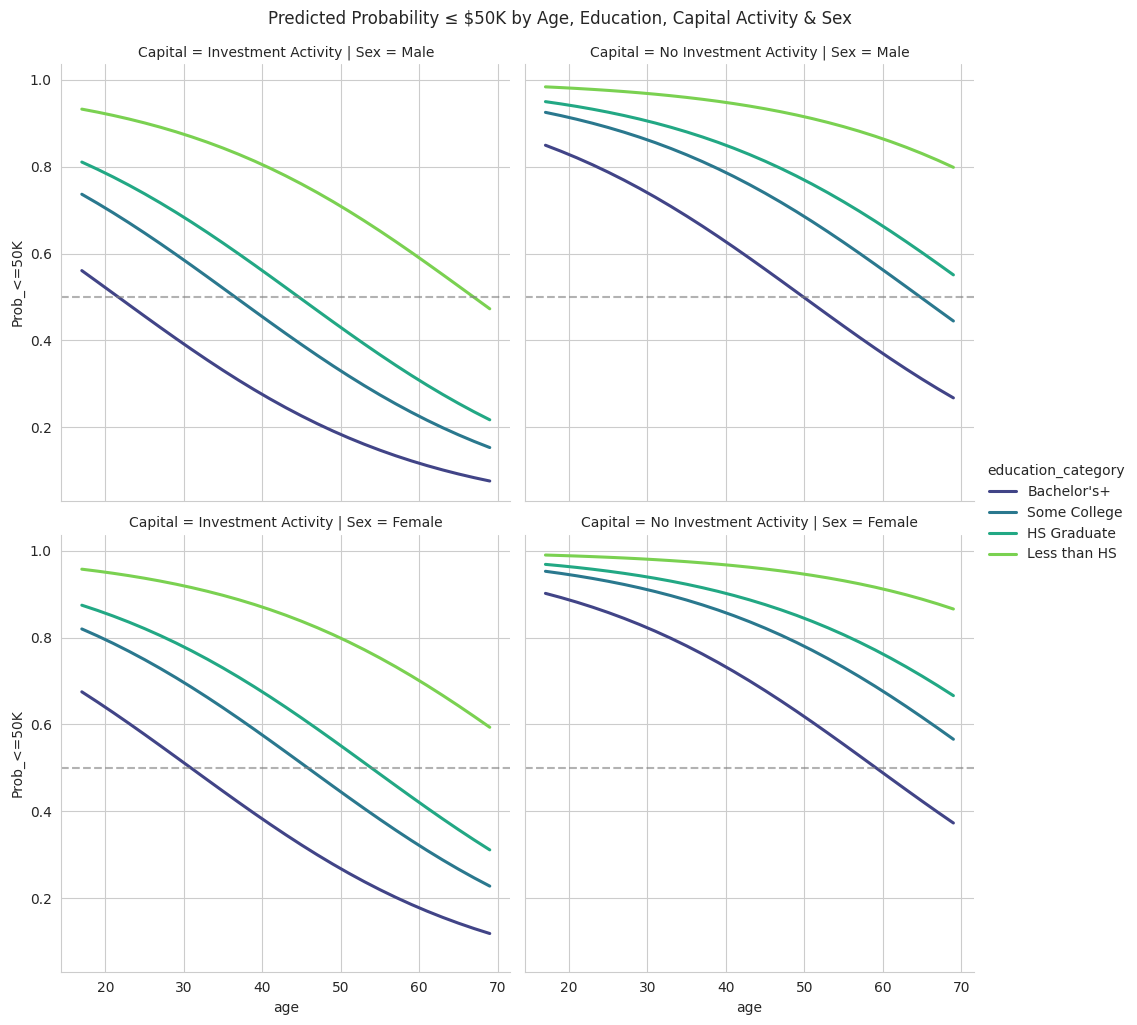

In [7]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('df_cleaned.csv')

# === EDUCATION BINNING (4 categories only) ===
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"

# Apply the binning
df['education_category'] = df['education'].apply(categorize_education)

# === Marriage Binning (2 categories only) ===
# Looking at the original Linear Regression Model the 5 not_married categories had a negative effect on probability
def categorize_marriage(mar):
    """Simplify marriage levels into 2 meaningful groups."""
    not_married = ['Divorced', 'Never-Married', 'Separated', 'Widowed', 'Married-spouse-absent']
    married = ['Married-civ-spouse', 'Married-AF-spouse']

    if mar in not_married:
        return 'Not Married'
    else:
        return "Married"

# Apply the marriage binning
df['marriage_category'] = df['marital-status'].apply(categorize_marriage)

# === Occupation Binning (2 categories only) ===
# Looking at the original Linear Regression Model, White Collar+First Responders give the highest weights
def categorize_occupation(occ):
    """Simplify occupation levels into 2 meaningful groups."""
    professional = ['Exec-managerial', 'Prof-specialty', 'Protective-serv', 'Tech-support', 'Sales', 'Craft-repair', 'Transport-moving']
    non_professional = ['Priv-house-serv', 'Farming-fishing', 'Other-service', 'Handlers-cleaners', 'Machine-op-inspct', 'Adm-clerical', 'Armed-Forces']

    if occ in professional:
        return 'professional'
    else:
        return "non-professional"

# Apply the occupation binning
df['occupation_category'] = df['occupation'].apply(categorize_occupation)

# === Capital Activity Binning (2 categories) ===
def categorize_capital_activity(gain, loss):
    """
    Bin capital-gain and capital-loss into two groups:
    - 'Investment Activity'   → either gain > 0 or loss > 0 (likely higher income signal)
    - 'No Investment Activity' → both gain = 0 and loss = 0
    """
    if gain > 0 or loss > 0:
        return 'Investment Activity'
    else:
        return 'No Investment Activity'

# Apply the binning (using both columns)
df['capital_activity'] = df.apply(lambda row: categorize_capital_activity(row['capital-gain'], row['capital-loss']), axis=1)

# === FEATURES (now using binned education) ===
features = ['age', 'education_category', 'sex', 'marriage_category', 'hours-per-week', 'occupation_category', 'capital_activity']
X = df[features]
y = df['income_binary']

# Identify column types
categorical_features = ['education_category', 'sex', 'marriage_category', 'occupation_category', 'capital_activity']
numeric_features = ['age', 'hours-per-week']

# Preprocessor: This code is used to transform data with mixed data (e.g. numerical, catergorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scales numeric features to mean = 0, std_dev = 1
        # OneHotEncoder converts categorical information to arbitrary binary values
         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a library with three models: Logistic Regression, Decision Tree, Random Forest
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, # balanced boosts minority class, random state for reproducibility
                                              solver='liblinear', max_iter=1000), # solver=Optimization algorithm, max_iter=1000 is default and no errors
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10), # pruning; max depth used to prevent overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

# Empty dictionaries to store results and fitted pipelines
results = {}
fitted_pipelines = {}

# Train and evaluate models
# This loop iterates over each model in the 'models' dictionary, applying the same preprocessing
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation, valuates model robustness on train data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit and predict trains the full pipeline on all train data then predicts on held-out test set
    # to gives unbiased performance estimates.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Stores the fitted pipelines by model name (LR, DT, RF)
    fitted_pipelines[name] = pipeline

    # Metrics, calculates test set metrics using scikit-learn functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL (with binned education)
print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name in models.keys():
    print(f"\n--- {name} ---") # Section name for each model
    current_pipeline = fitted_pipelines[name] # Retrieves the fitted model by name
    fitted_model = current_pipeline.named_steps['model']

    # Get feature names (includes binned education_category)
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = np.concatenate([
        numeric_features,
        cat_encoder.get_feature_names_out(categorical_features)
    ])

    if name == 'Logistic Regression':
        intercept = fitted_model.intercept_[0] # Gets the model's intercept
        coef = fitted_model.coef_[0] # Gets the models coefficients
        print("Logistic Regression (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}") # Prints the intercept
        for feat, c in zip(feature_names, coef): # Prints the weight multiplied by feature, eliminates small features with abs(c)>0.001
            if abs(c) > 0.001:
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    elif name == 'Decision Tree':
        from sklearn.tree import export_text # This command converts tree to text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model, feature_names=feature_names.tolist(), # Prints tree in readable text
                          max_depth=5, spacing=3))

    elif name == 'Random Forest':
        importances = fitted_model.feature_importances_ #Feature importances
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=False) # Sort by decending importance
        print("Random Forest (ensemble) \u2192 no single formula")
        print("Top 10 Feature Importances:")
        print(imp_df.head(10).round(4))

print("\n" + "="*80)

# ────────────────────────────────────────
# Plot: Probability of >$50K by Age, split by Sex and Education
# Using Logistic Regression (as requested)
# ────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare common grid parameters
age_range = np.arange(17, 91, 2)           # realistic ages from dataset
edu_levels = ["Bachelor's+", "Some College", "HS Graduate", "Less than HS"]

# Fixed values (feel free to change)
fixed_hours = 40
fixed_marriage = 'Not Married'
fixed_occupation = 'non_professional'
fixed_capital = 'No Investment Activity'

# ────────────────────────────────────────
# Plot 1: Males
# ────────────────────────────────────────

grid_male = pd.DataFrame(
    list(product(age_range, edu_levels)),
    columns=['age', 'education_category']
)

grid_male['sex'] = 'Male'
grid_male['marriage_category'] = fixed_marriage
grid_male['hours-per-week'] = fixed_hours
grid_male['occupation_category'] = fixed_occupation
grid_male['capital_activity'] = fixed_capital

# Predict with Logistic Regression
lr_pipeline = fitted_pipelines['Logistic Regression']
probs_male = lr_pipeline.predict_proba(grid_male)[:, 1]
grid_male['Prob_>50K'] = probs_male

# Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=grid_male,
    x='age',
    y='Prob_>50K',
    hue='education_category',
    hue_order=edu_levels[::-1],  # Bachelor's+ on top
    palette='viridis',
    linewidth=2.8,
    markers=True,
    dashes=False
)

plt.title("8-Factor Logistic Regression: Predicted Probability of Income > $50K\n"
          "Males – by Age and Education Level\n"
          f"({fixed_marriage}, {fixed_hours}, {fixed_occupation}, {fixed_capital})",
          fontsize=14, pad=15)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Predicted Probability > $50K", fontsize=12)
plt.ylim(0, 1)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6)

plt.axvline(x=65, color='red', linestyle='--', linewidth=2.5,
            label='Typical Retirement Age (65)')

plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# Plot 2: Females
# ────────────────────────────────────────

grid_female = pd.DataFrame(
    list(product(age_range, edu_levels)),
    columns=['age', 'education_category']
)

grid_female['sex'] = 'Female'
grid_female['marriage_category'] = fixed_marriage
grid_female['hours-per-week'] = fixed_hours
grid_female['occupation_category'] = fixed_occupation
grid_female['capital_activity'] = fixed_capital

# Predict with Logistic Regression
probs_female = lr_pipeline.predict_proba(grid_female)[:, 1]
grid_female['Prob_>50K'] = probs_female

# Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=grid_female,
    x='age',
    y='Prob_>50K',
    hue='education_category',
    hue_order=edu_levels[::-1],
    palette='viridis',
    linewidth=2.8,
    markers=True,
    dashes=False
)

plt.title("8-Factor Logistic Regression: Predicted Probability of Income > $50K\n"
          "Females – by Age and Education Level\n"
          f"({fixed_marriage}, {fixed_hours}, {fixed_occupation}, {fixed_capital})",
          fontsize=14, pad=15)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Predicted Probability > $50K", fontsize=12)
plt.ylim(0, 1)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6)

plt.axvline(x=65, color='red', linestyle='--', linewidth=2.5,
            label='Typical Retirement Age (65)')

plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# Plot 2: Females professionals with stock, unmarried
# ────────────────────────────────────────

grid_female = pd.DataFrame(
    list(product(age_range, edu_levels)),
    columns=['age', 'education_category']
)

grid_female['sex'] = 'Female'
grid_female['marriage_category'] = fixed_marriage
grid_female['hours-per-week'] = fixed_hours
grid_female['occupation_category'] = 'professional'
grid_female['capital_activity'] = 'Investment Activity'

# Predict with Logistic Regression
probs_female = lr_pipeline.predict_proba(grid_female)[:, 1]
grid_female['Prob_>50K'] = probs_female

# Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=grid_female,
    x='age',
    y='Prob_>50K',
    hue='education_category',
    hue_order=edu_levels[::-1],
    palette='viridis',
    linewidth=2.8,
    markers=True,
    dashes=False
)

plt.title("8-Factor Logistic Regression: Predicted Probability of Income > $50K\n"
          "Females – by Age and Education Level\n"
          f"(Unmarried, {fixed_hours}, Professional, With Investments)",
          fontsize=14, pad=15)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Predicted Probability > $50K", fontsize=12)
plt.ylim(0, 1)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6)

plt.axvline(x=65, color='red', linestyle='--', linewidth=2.5,
            label='Typical Retirement Age (65)')

plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# Plot: Probability > $50K by Age – With vs Without Investments
# Using Logistic Regression

# Grid parameters
age_range = np.arange(17, 70, 2)           # realistic age range

investment_status = [
    'Investment Activity',      # gain > 0 or loss > 0
    'No Investment Activity'    # both = 0
]

# Create base grid
plot_grid = pd.DataFrame(
    list(product(age_range, investment_status)),
    columns=['age', 'capital_activity']
)

# Reasonable fixed values (averages / typical values)
plot_grid['sex'] = 'Male'                     # or average both sexes if preferred
plot_grid['education_category'] = "Bachelor's+"  # or loop over levels if you want facets
plot_grid['marriage_category'] = 'Not Married'
plot_grid['hours-per-week'] = 40
plot_grid['occupation_category'] = 'professional'

# Predict probabilities using Logistic Regression
lr_pipeline = fitted_pipelines['Logistic Regression']
probs = lr_pipeline.predict_proba(plot_grid)[:, 1]
plot_grid['Prob_>50K'] = probs

# ────────────────────────────────────────
# Create the line plot
# ────────────────────────────────────────

plt.figure(figsize=(13, 7.5))
sns.set_style("whitegrid")

sns.lineplot(
    data=plot_grid,
    x='age',
    y='Prob_>50K',
    hue='capital_activity',
    hue_order=['Investment Activity', 'No Investment Activity'],
    palette=['#2ca02c', '#d62728'],   # green = with, red = without
    linewidth=3.2,
    markers=True,
    markersize=9,
    dashes=False
)

# Retirement marker
plt.axvline(x=65, color='darkgray', linestyle='--', linewidth=2.8,
            label='Typical Retirement Age (65)')

plt.title("Logistic Regression: Predicted Probability of Income > $50K\n"
          "by Age – With vs Without Investment Activity\n"
          "(Married, 40 hrs/week, Professional occupation, Bachelor's+ education, Male)",
          fontsize=15, pad=18)

plt.xlabel("Age", fontsize=13)
plt.ylabel("Predicted Probability > $50K", fontsize=13)

plt.ylim(0, 1.02)
plt.xlim(15, 92)

plt.axhline(0.5, color='lightgray', linestyle='--', alpha=0.5)

plt.legend(title="Investment Activity",
           bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11,
           title_fontsize=12)

plt.grid(True, alpha=0.35, linestyle=':')
plt.tight_layout()
plt.show()

# ===================================================================
# Heat Map education, captial_activity, occupation

# Choose two strong categorical variables to cross-tabulate
var1 = 'education_category'
var2 = 'capital_activity'
var3 = 'occupation_category'

# Realistic age (fixed)
fixed_age = 45
fixed_sex = 'Male'              # Males is the limiting case
fixed_marriage = 'Not Married'
fixed_hours = 40

# Create grid of combinations
grid = pd.DataFrame(
    list(product(df[var1].unique(), df[var2].unique(), df[var3].unique())),
    columns=[var1, var2, var3]
)

# Add fixed columns
grid['age'] = fixed_age
grid['sex'] = fixed_sex
grid['marriage_category'] = fixed_marriage
grid['hours-per-week'] = fixed_hours

# Predict probability of >50K, then flip to get P(≤50K)
lr = fitted_pipelines['Logistic Regression']
probs = lr.predict_proba(grid)[:, 1]          # P(>50K)
grid['Prob_≤50K'] = 1 - probs

# Pivot for heatmap (average over third variable if needed)
heatmap_data = grid.pivot_table(
    values='Prob_≤50K',
    index=var1,
    columns=var2,
    aggfunc='mean'
)

# Order categories logically
heatmap_data = heatmap_data.reindex(
    index=["Bachelor's+", "Some College", "HS Graduate", "Less than HS"]
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',           # greem = high ≤50K probability, red = low
    cbar_kws={'label': 'Probability of ≤ $50K'},
    linewidths=0.5
)

plt.title(f"Predicted Probability of Income ≤ $50K\n"
          f"by Education and Capital Activity\n"
          f"(Age {fixed_age}, {fixed_sex}, {fixed_marriage}, {fixed_hours} hrs, {fixed_sex} occupation)",
          fontsize=14)

plt.xlabel("Capital Activity")
plt.ylabel("Education Level")
plt.tight_layout()
plt.show()

# ======================================================================
# Facet Plot to show both occupations, professional and non-professional

# Define variables for the facet plot
age_range_facet = np.arange(17, 70, 2)
edu_levels_facet = ["Bachelor's+", "Some College", "HS Graduate", "Less than HS"]
sexes_facet = ['Male', 'Female']
capital_activity_facet = ['Investment Activity', 'No Investment Activity']

# Create a new plot_grid for the facet plot
plot_grid_facet = pd.DataFrame(
    list(product(age_range_facet, edu_levels_facet, sexes_facet, capital_activity_facet)),
    columns=['age', 'education_category', 'sex', 'capital_activity']
)

# Fixed values for other variables in this facet plot
fixed_marriage_facet = 'Not Married'
fixed_hours_facet = 40
fixed_occupation_facet = 'professional'

plot_grid_facet['marriage_category'] = fixed_marriage_facet
plot_grid_facet['hours-per-week'] = fixed_hours_facet
plot_grid_facet['occupation_category'] = fixed_occupation_facet

# Predict probabilities
lr_pipeline = fitted_pipelines['Logistic Regression']
probs_facet = lr_pipeline.predict_proba(plot_grid_facet)[:, 1]
plot_grid_facet['Prob_>50K'] = probs_facet
plot_grid_facet['Prob_<=50K'] = 1 - probs_facet # New column for the y-axis

g = sns.relplot(
    data=plot_grid_facet,               # Use the newly created facet grid
    x='age',
    y='Prob_<=50K',                # Use the column name from the facet grid
    hue='education_category',
    col='capital_activity',
    row='sex',
    kind='line',
    palette='viridis',
    linewidth=2.2,
    facet_kws={'sharey': True}
)

# Add a reference line at 0.5 to each subplot
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6)

g.set_titles("Capital = {col_name} | Sex = {row_name}")
g.fig.suptitle("Predicted Probability ≤ $50K by Age, Education, Capital Activity & Sex", y=1.02)
plt.show()

**CONCLUSION - Eight-Parameter Model vs. Full Fourteen-Parameter Model**

All-Feature Model

| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression |**0.683(±0.006)**    | 0.806         | 0.574          | **0.846**       | **0.684**   |
| Decision Tree       | 0.670 (±0.003)    | 0.799         | 0.563          | 0.843       | 0.675   |
| Random Forest       | 0.630 (±0.012)    | **0.833**         | **0.683**          | 0.612       | 0.646   |

Eight-Feature Model
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.621 (±0.005)    | 0.761         | 0.513          | 0.792       | 0.623   |
| Decision Tree       | 0.619 (±0.006)    | 0.754         | 0.504          | **0.803**   | 0.619   |
| Random Forest       | 0.584 (±0.007)    | **0.768**     | **0.528**      | 0.647       | 0.581   |



**LOGISTIC REGRESSION is the best overall performer for the Eight-Factor Model.**  This 8-factor model uses binary input easily explainable to the marketing department.  For this model, we are using:


*   Married/Not Married
*   Male/Female
*   Professional (White Collar) + Skilled Trade Workers vs. not
*   Capital Activity (having a brokerage account is a good binary substitute)
*   Age
*   Hours per week (full-time vs. part-time or unemployed is equivalent)
*   Education (Less than HS, HS, Some College, Bachelors+)

The Logistic Regression Model is easy to understand and explain:

Logistic Regression (log-odds):

$  log(p / (1-p)) =   1.1448$

                 +   0.7163 * age
                 +   0.4478 * hours-per-week
                 +  -1.2104 * education_category_HS Graduate
                 +  -2.3830 * education_category_Less than HS
                 +  -0.7841 * education_category_Some College
                 +   0.4869 * sex_Male
                 +  -1.5311 * marriage_category_Not Married
                 +   0.8638 * occupation_category_professional
                 +  -1.4859 * capital_activity_No Investment Activity
(p = probability of income > $50K)


All-Feature Model

| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression |**0.683(±0.006)**    | 0.806         | 0.574          | **0.846**       | **0.684**   |
| Decision Tree       | 0.670 (±0.003)    | 0.799         | 0.563          | 0.843       | 0.675   |
| Random Forest       | 0.630 (±0.012)    | **0.833**         | **0.683**          | 0.612       | 0.646   |

Four-Feature Model (Age, Sex, Education, Income)
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.560 (±0.007)    | 0.723         | 0.464          | 0.724       | 0.566   |
| Decision Tree       | 0.577 (±0.006)    | 0.728         | 0.471          | **0.757**   | **0.581** |
| Random Forest       | 0.576 (±0.005)    | **0.730**     | **0.473**      | 0.754       | **0.581** |

Five-Feature Model (Age, Sex, Education, Income, Marital Status)
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.584 (±0.005)    | 0.736         | 0.481          | 0.751       | 0.586   |
| Decision Tree       | 0.593 (±0.005)    | 0.736         | 0.482          | **0.811**   | **0.604** |
| Random Forest       | 0.592 (±0.002)    | 0.736         | 0.482          | 0.806       | 0.603   |

Six-Parameter Model (Age, Sex, Education, Income, Marital Status, Hours Per Week)
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.592 (±0.004)    | 0.743         | 0.489          | 0.774       | 0.599   |
| Decision Tree       | 0.603 (±0.005)    | 0.739         | 0.486          | **0.805**   | **0.606** |
| Random Forest       | 0.574 (±0.005)    | **0.752**     | **0.501**      | 0.682       | 0.577   |

Seven-Parameter Model (Age, Sex, Education, Income, Marital Status,

Occupation, Hours per Week)
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.600 (±0.003)    | 0.745         | 0.493          | 0.789       | 0.607   |
| Decision Tree       | 0.601 (±0.004)    | 0.747         | 0.495          | **0.818**   | **0.616** |
| Random Forest       | 0.576 (±0.005)    | **0.759**     | **0.512**      | 0.677       | 0.583   |

Eight-Feature Model (Age, Sex, Education, Income, Marital Status, Occupation,

Hours per Week, Capital Activity (gain or loss, none)
| Model               | CV F1 Mean (±Std) | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---------------------|-------------------|---------------|----------------|-------------|---------|
| Logistic Regression | 0.621 (±0.005)    | 0.761         | 0.513          | 0.792       | 0.623   |
| Decision Tree       | 0.619 (±0.006)    | 0.754         | 0.504          | **0.803**   | 0.619   |
| Random Forest       | 0.584 (±0.007)    | **0.768**     | **0.528**      | 0.647       | 0.581   |